In [ ]:
"""
Step 1 -- Problem Definition:

Goal?
    Get this model to learn normal network behavior from the dataset, which when identified it will be able 
    to flag unusual traffic patterns.
    This allows for quicker and more efficient responses to cyber threats.

TODO: 
    ID METRICS FOR SUCCESS OF THIS PROJECT!! 
        IE) Accuracy, Reduced false alarms (true/False positives, true/false negatives)????

    ID CONSTRAINTS
        IE) Data availability, latency, compliance, cost????
    

Traffic patterns can indicate:
    Zero-day Attacks, 
    Malware Beaconing, 
    Lateral Movement, 
    Data Exfiltration, 
    Suspicious Geo-Location Anomalies, 
    Port Scanning / Probing.
"""

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
"""
Step 2 -- Data Collection:


Data was collected from the following dataset:
    https://www.kaggle.com/datasets/teamincribo/cyber-security-attacks/

The dataset is said to consist "of 25 varied metrics and 40,000 records". 

Example data collected includes: 
    Firewall Logs, IDS/IPS Alerts, Source IP Address, Destination Port, Protocol, etc...


This dataset should be large enough to be feasible for a personal project on network anomaly detection.   
"""

In [2]:
# This cell loads the dataset from a csv file into a pandas dataframe.
df = pd.read_csv("cybersecurity_attacks.csv")

In [4]:
"""
Step 3 -- Data Exploration & Profiling:


"""


'\nStep 3 -- Data Exploration & Profiling:\n\n\n'

In [19]:
"""
This cell gives a quick overview on the dataset:

"""

# Below allows us to see the full output under the explanation column. 
pd.set_option("display.max_colwidth", None)

# The below 2 lines allow us to see all dataframe columns in the output, without any being cutoff. 
pd.set_option("display.max_columns", None) # Shows all columns.
pd.set_option("display.width", None) # Don't wrap lines or force dataframe to fit insiude a narrow console width. 

# Basic structure 
# Confirms columns and their data types, shows memory usage, and shows non-null value counts for each column. 
df.info()
print("\n\n\n")

# Quick preview of the top 10 rows from the dataframe.
df.head(10)


<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               40000 non-null  str    
 1   Source IP Address       40000 non-null  str    
 2   Destination IP Address  40000 non-null  str    
 3   Source Port             40000 non-null  int64  
 4   Destination Port        40000 non-null  int64  
 5   Protocol                40000 non-null  str    
 6   Packet Length           40000 non-null  int64  
 7   Packet Type             40000 non-null  str    
 8   Traffic Type            40000 non-null  str    
 9   Payload Data            40000 non-null  str    
 10  Malware Indicators      20000 non-null  str    
 11  Anomaly Scores          40000 non-null  float64
 12  Alerts/Warnings         19933 non-null  str    
 13  Attack Type             40000 non-null  str    
 14  Attack Signature        40000 non-null  str    
 

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Payload Data,Malware Indicators,Anomaly Scores,Alerts/Warnings,Attack Type,Attack Signature,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,Qui natus odio asperiores nam. Optio nobis iusto accusamus ad perferendis esse at. Asperiores neque at ad.\nMaiores possimus ipsum saepe vitae. Ad possimus veritatis.,IoC Detected,28.67,NaN,Malware,Known Pattern B,Logged,Low,Reyansh Dugal,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT 6.2; Trident/5.0),Segment A,"Jamshedpur, Sikkim",150.9.97.135,Log Data,NaN,Server
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,Aperiam quos modi officiis veritatis rem. Omnis nulla dolore perspiciatis.\nIllo animi mollitia vero voluptates error ad. Quidem maxime eaque optio a. Consectetur quasi veniam et totam culpa ullam.,IoC Detected,51.50,NaN,Malware,Known Pattern A,Blocked,Low,Sumer Rana,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT 6.0; Trident/4.0),Segment B,"Bilaspur, Nagaland",NaN,Log Data,NaN,Firewall
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,Perferendis sapiente vitae soluta. Hic delectus quae nemo ea esse est rerum.,IoC Detected,87.42,Alert Triggered,DDoS,Known Pattern B,Ignored,Low,Himmat Karpe,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT 6.2; Trident/5.0),Segment C,"Bokaro, Rajasthan",114.133.48.179,Log Data,Alert Data,Firewall
3,2023-07-02 10:38:46,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,Totam maxime beatae expedita explicabo porro labore. Minima ab fugit officiis dicta perspiciatis pariatur. Facilis voluptates eligendi dolores eveniet deserunt. Eveniet reprehenderit culpa quo.,NaN,15.79,Alert Triggered,Malware,Known Pattern B,Blocked,Medium,Fateh Kibe,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_11_5; rv:1.9.6.20) Gecko/2583-02-14 13:30:10 Firefox/11.0,Segment B,"Jaunpur, Rajasthan",NaN,NaN,Alert Data,Firewall
4,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,Odit nesciunt dolorem nisi iste iusto. Animi voluptates soluta quis doloribus quas. Iure harum nihil hic illo repellendus.\nQuia illo fugit eligendi doloremque. In doloremque autem iure.,NaN,0.52,Alert Triggered,DDoS,Known Pattern B,Blocked,Low,Dhanush Chad,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT 6.2; Trident/3.0),Segment C,"Anantapur, Tripura",149.6.110.119,NaN,Alert Data,Firewall
5,2022-10-28 13:14:27,198.102.5.160,147.190.155.133,17430,52805,UDP,1423,Data,HTTP,Repellat quas illum harum fugit incidunt exercitationem illum. Voluptate asperiores aperiam magnam eius. Eos quis repellat eos.,NaN,5.76,NaN,Malware,Known Pattern A,Logged,Medium,Zeeshan Viswanathan,Opera/8.58.(X11; Linux i686; nl-NL) Presto/2.9.170 Version/12.00,Segment C,"Aurangabad, Meghalaya",NaN,NaN,NaN,Server
6,2022-05-16 17:55:43,97.253.103.59,77.16.101.53,26562,17416,TCP,379,Data,DNS,Qui numquam inventore repellat ratione fugit odit. Quidem est possimus voluptates reprehenderit vitae a. Quibusdam in itaque rerum.\nExcepturi quisquam iusto provident adipisci.,NaN,31.55,NaN,DDoS,Known Pattern B,Ignored,High,Ehsaan Dalal,Opera/9.24.(X11; Linux i686; fa-IR) Presto/2.9.175 Version/10.00,Segment A,"Eluru, Manipur",NaN,Log Data,NaN,Server
7,2023-02-12 07:13:17,11.48.99.245,178.157.14.116,34489,20396,ICMP,1022,Data,DNS,Amet libero optio quidem praesentium libero. Ea magnam atque corporis ipsum iure iusto.\nEveniet dolor odio libero. Minus iste fugit asperiores minima eos ipsum.,IoC Detected,54.05,Alert Triggered,Intrusion,Known Pattern A,Logged,High,Yuvaan Dubey,"Mozilla/5.0 (Macintosh; U; PPC Mac OS X 10_7_6) AppleWebKit/534.2 (KHTML, like Gecko) Chrome/45.0.865.0 Safari/534.2",Segment A,"Phagwara, Andhra Pradesh",192.31.159.5,Log Data,Aler

In [5]:
"""
This cell checks for missing values:

Why?
    Columns with many missing values may need imputation or removal.
    Missingness patterns can indicate corrupted data or logging failures.


Results?
    We can see that there are 5 columns that have missing data, and that these columns are missing around half 
    of their datapoints.

    Typically when we are missing so many datapoints from a column, it should be removed from the set prior to 
    further modeling.
    
"""

df.isna().sum().sort_values(ascending=False)

Alerts/Warnings           20067
IDS/IPS Alerts            20050
Malware Indicators        20000
Firewall Logs             19961
Proxy Information         19851
Source IP Address             0
Destination IP Address        0
Source Port                   0
Timestamp                     0
Traffic Type                  0
Packet Type                   0
Packet Length                 0
Protocol                      0
Destination Port              0
Attack Type                   0
Payload Data                  0
Anomaly Scores                0
Severity Level                0
Action Taken                  0
Attack Signature              0
User Information              0
Geo-location Data             0
Network Segment               0
Device Information            0
Log Source                    0
dtype: int64

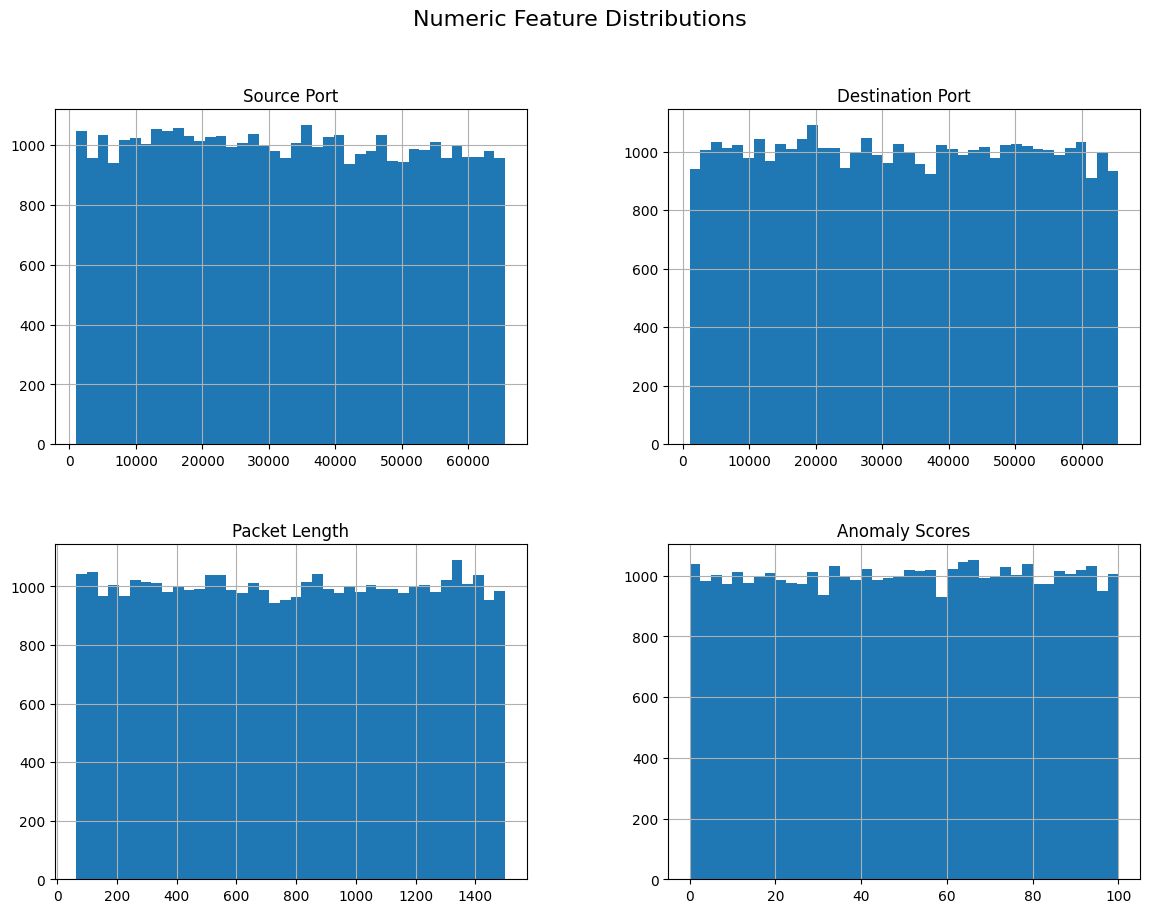

In [21]:
"""
This cell performs a distirbution check on the datasets numeric features:


Why?
    Different distributions 


NOTE: 
    Results didn't show anything useful. 
        I don't know how to proceed. 

    TODO: Take picture and ask AI to interpret results!!!
    *********************************************ABOVE*****************
"""

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[numeric_cols].hist(bins=40, figsize=(14,10))
plt.suptitle("Numeric Feature Distributions", fontsize=16)
plt.show()



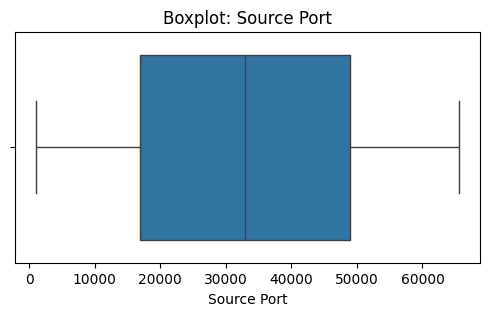

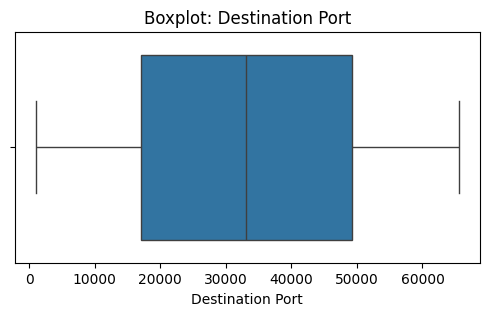

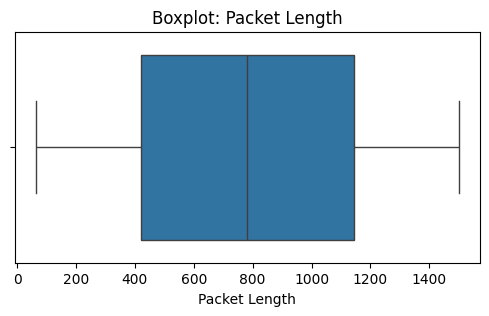

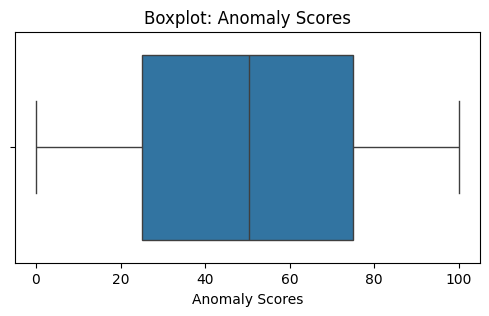

In [22]:
"""
This cell detects outliers:

"""

for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot: {col}")
    plt.show()
    print("\n\n")



In [24]:
"""
This cell performs a correlation analysis on the columns (AKA features) of the dataframe.

This yields a correlation heatmap of the features that tend to move together, and those that don't.

Note: This is for categorical features only!

Why?
    Detection of rate categories and imbalanced classes, 
    and is useful due to the number of categorical columns we are workign with. (Port categories, protocols ...) 
"""

categorical_cols = df.select_dtypes(include=['object', 'string']).columns

for col in categorical_cols:
    print(f"\nValue counts for {col}:\n")    
    print(df[col].value_counts().head(10))
    print("\n\n\n")



Value counts for Timestamp:

Timestamp
2022-04-17 20:05:34    2
2022-06-06 12:12:43    2
2022-06-11 14:28:15    2
2023-05-30 06:33:58    1
2020-08-26 07:08:30    1
2022-11-13 08:23:25    1
2023-07-02 10:38:46    1
2023-07-16 13:11:07    1
2022-10-28 13:14:27    1
2022-05-16 17:55:43    1
Name: count, dtype: int64





Value counts for Source IP Address:

Source IP Address
103.216.15.12      1
78.199.217.198     1
63.79.210.48       1
163.42.196.10      1
71.166.185.76      1
198.102.5.160      1
97.253.103.59      1
11.48.99.245       1
49.32.208.167      1
114.109.149.113    1
Name: count, dtype: int64





Value counts for Destination IP Address:

Destination IP Address
84.9.164.252       1
66.191.137.154     1
198.219.82.17      1
101.228.192.255    1
189.243.174.238    1
147.190.155.133    1
77.16.101.53       1
178.157.14.116     1
72.202.237.9       1
160.88.194.172     1
Name: count, dtype: int64





Value counts for Protocol:

Protocol
ICMP    13429
UDP     13299
TCP     1327

In [26]:
"""
Leakage Risk Scan:

Leakage?
    When a column contains information that would not be available at prediction time, 

    This could result in greater model performance during validation, but worse actual results 
    as the model has learned patterns it wouldn’t have access to in a real scenario. 


Why?
    This would ensure we do not include things such as the following during model training and evaluation: 
        Anomaly labels,
        IDS alerts,
        firewall verdicts,
        post‑hoc scores.


Results?
    This IDs that there is no leakage!
        This is because the only column that matches the 

"""

leakage_suspects = [
    col for col in df.columns
    if "label" in col.lower() or "score" in col.lower()
]

leakage_suspects


['Anomaly Scores']

In [28]:
"""
This cell performs a Z-Score check to ID the dataset's outliers:

Why? 
    This allows to ID outliers, and helps in deciding if we need do something with them. 
"""

from scipy.stats import zscore

z_scores = df[numeric_cols].apply(zscore)
outliers = (abs(z_scores) > 3).sum().sort_values(ascending=False)
outliers

Source Port         0
Destination Port    0
Packet Length       0
Anomaly Scores      0
dtype: int64

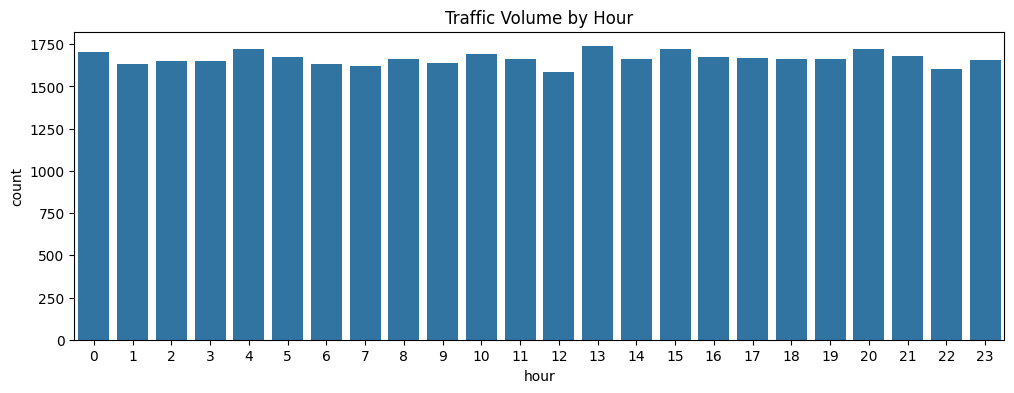

In [29]:
""" 
Time Based Profiling: 

Why?
    Allow us to see time based patterns (Daily) 
    and thus we can ID times at which anomalies spike. 


NOTE: 
    This cell does not show anomalous traffic, but all traffic. 
        
        TODO: Create a cell later in the pipeline that shows time based profiling for only anomalous traffic.
        
"""

df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")


df["hour"] = df["Timestamp"].dt.hour

plt.figure(figsize=(12,4))
sns.countplot(data=df, x="hour")
plt.title("Traffic Volume by Hour")
plt.show()


In [3]:
"""
Step 4 -- Data Cleansing and preprocessing:

"""

# Drop columns that are pure identifiers (optional)
drop_cols = ["Timestamp", "Source IP Address", "Destination IP Address",
             "User Information", "Device Information", "Log Source"]

df_clean = df.drop(columns=drop_cols, errors="ignore")

In [6]:
"""
Feature Engineering:

Here we build features that aid the model in detecting patterns. We do this by transforming raw input 
(from network logs), into features. (Numerical or categorical)

This is because raw fields like IP addresses, ports, payloads, and log messages are not directly useful to the ML 
model. They still need to be cleaned, normalized, encoded, aggregated, and transformed into behavioral indicators. 
"""

'\nFeature Engineering:\n\nHere we build features that aid the model in detecting patterns. We do this by transforming raw input \n(from network logs), into features. (Numerical or categorical)\n\nThis is because raw fields like IP addresses, ports, payloads, and log messages are not directly useful to the ML model\n'

In [4]:
"""

This cell drops columns that are not well suited for the isolated forest model.

These columns are either: to large, too unique, too unstructured, or have too many missing values.

"""


drop_cols = [
    "Payload Data",        # raw text → use entropy instead
    "User Information",    # too many unique values
    "Device Information",  # too many unique values
    "Firewall Logs",       # long text → extract length instead
    "IDS/IPS Alerts",      # long text → extract count instead
    "Log Source",          # high-cardinality
    "Network Segment"      # optional: drop unless small number of segments

    # The below columns only abot half of their rows with non-null data points in them 
    # (They can be uncommented and removed if needed. But if done so, the below cells will need to be changed)
    # "Alerts/Warnings", 
    # "IDS/IPS Alerts", 
    # "Malware Indicators",
    # "Firewall Logs", 
    # "Proxy Information"
]

df_clean = df.drop(columns=drop_cols, errors="ignore")
df_clean.head(10)

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Malware Indicators,Anomaly Scores,Alerts/Warnings,Attack Type,Attack Signature,Action Taken,Severity Level,Geo-location Data,Proxy Information
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,IoC Detected,28.67,NaN,Malware,Known Pattern B,Logged,Low,"Jamshedpur, Sikkim",150.9.97.135
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,IoC Detected,51.50,NaN,Malware,Known Pattern A,Blocked,Low,"Bilaspur, Nagaland",NaN
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,IoC Detected,87.42,Alert Triggered,DDoS,Known Pattern B,Ignored,Low,"Bokaro, Rajasthan",114.133.48.179
3,2023-07-02 10:38:46,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,NaN,15.79,Alert Triggered,Malware,Known Pattern B,Blocked,Medium,"Jaunpur, Rajasthan",NaN
4,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,NaN,0.52,Alert Triggered,DDoS,Known Pattern B,Blocked,Low,"Anantapur, Tripura",149.6.110.119
5,2022-10-28 13:14:27,198.102.5.160,147.190.155.133,17430,52805,UDP,1423,Data,HTTP,NaN,5.76,NaN,Malware,Known Pattern A,Logged,Medium,"Aurangabad, Meghalaya",NaN
6,2022-05-16 17:55:43,97.253.103.59,77.16.101.53,26562,17416,TCP,379,Data,DNS,NaN,31.55,NaN,DDoS,Known Pattern B,Ignored,High,"Eluru, Manipur",NaN
7,2023-02-12 07:13:17,11.48.99.245,178.157.14.116,34489,20396,ICMP,1022,Data,DNS,IoC Detected,54.05,Alert Triggered,Intrusion,Known Pattern A,Logged,High,"Phagwara, Andhra Pradesh",192.31.159.5
8,2023-06-27 11:02:56,49.32.208.167,72.202.237.9,56296,20857,TCP,1281,Control,FTP,IoC Detected,56.34,Alert Triggered,Intrusion,Known Pattern A,Blocked,High,"Ambala, Tripura",NaN
9,2021-08-15 22:29:04,114.109.149.113,160.88.194.172,37918,50039,UDP,224,Data,HTTP,NaN,16.51,Alert Triggered,Malware,Known Pattern B,Blocked,Medium,"Rampur, Mizoram",87.128.245.244


In [5]:
"""
Port Binning:

Ports are integers numbered from 0 to 65535, and each represent a service running on the host machine.

Port Ranges: (Bins)
0-1023 --> Well known ports. (HTTP, SSH, Telnet etc...)
1024-49151 --> Registered ports. (Vendor specific services, apps...)
49152-65535 --> Dynamic/Ephemeral ports (Temporary client side ports)

Why bin ports?
    There are specific patterns associated with each bin. 
        Well known ports are scanned more often, 
        Registered ports are more frequently targeted by abuse, 
        dynamic ports more often used for command and control, 
        communication is made on ports that don't match expected services.

    Traffic on port 4444? Raise red flag! This port is often used in attacks with Metasploit!

    This allows the model to learn things such as:
        Normal traffic uses ephemeral ports for outbound conections, 
        A brute force attacks may be occurring when a port is hit repeatedly, 
        malware beaconing often uses high dynamic ports.

            Malware beaconing? infected device quietly communicates with the command and control server at 
            regular intervals. (This small, repetitive outbound communication is often made to unusual IPs, often  
            on dynamic ports, with high entropy payloads.

"""
def port_category(port):
    if port <= 1023:
        return "well_known"
    elif port <= 49151:
        return "registered"
    else:
        return "dynamic"

df_clean["SourcePortCat"] = df_clean["Source Port"].apply(port_category)
df_clean["DestPortCat"] = df_clean["Destination Port"].apply(port_category)

print("SourcePortCat" in df_clean.columns)
print("DestPortCat" in df_clean.columns)


True
True


In [6]:
"""
Payload Entropy:
    Measures how random the payload data is.


High entropy may ID:
    Encrypted Payloads, 
    Compressed Payloads, 
    Obfuscated Malware,
    Packed Binaries, 
    Exfiltration of Encrypted Data. 

Low entropy may ID: 
    Plain Text, 
    Logs, 
    Normal HTTO Traffic, 
    Simple Commands.


We will be using the Shannon Entropy Formula to calculate entropy. 
    The result value from this equation can be interpreted as such:
        0-3 --> Very predictable (Plain text, logs)
        3-6 --> Mixed content (Normal web traffic) 
        7-8 --> Highly random (Encryption, malware, exfiltration)


Why entropy?
    It is a very strong signal for malware payloads, spotting data exfiltration, 
    identifying suspicious binary blobs, and flagging obfuscated scripts (Powershell, JavaScript, VBA).  

"""

import numpy as np

def shannon_entropy(data):
    if not isinstance(data, str) or len(data) == 0:
        return 0
    probabilities = [data.count(c) / len(data) for c in set(data)]
    return -sum(p * np.log2(p) for p in probabilities)

df_clean["PayloadEntropy"] = (
    df_clean["Malware Indicators"]
    .fillna("")
    .astype(str)
    .apply(shannon_entropy)
)

print("PayloadEntropy" in df_clean.columns)



True


In [7]:
print(df_clean.columns.tolist())


['Timestamp', 'Source IP Address', 'Destination IP Address', 'Source Port', 'Destination Port', 'Protocol', 'Packet Length', 'Packet Type', 'Traffic Type', 'Malware Indicators', 'Anomaly Scores', 'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken', 'Severity Level', 'Geo-location Data', 'Proxy Information', 'SourcePortCat', 'DestPortCat', 'PayloadEntropy']


In [8]:
"""
Feature Selection:

This cell selects features for modeling.

"""  


# These features are small and safe to encode.
categorical_features = [
    "Protocol",
    "Packet Type",
    "Traffic Type",
    "Action Taken",
    "Country",
    "SourcePortCat",
    "DestPortCat"
]

numeric_features = [
    "Packet Length",
    "Anomaly Scores",
    "Severity Level",
    "FirewallLogLength",
    "IDSAlertCount",
    "PayloadEntropy"
]

In [9]:
"""

Data Preprocessing:

"""
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [10]:
"""
This cell encodeds the severity level column into a numerical column that the isolation forest is able to work 
with.


"""

severity_map = {
    "Low": 1,
    "Medium": 2,
    "High": 3,
    "Critical": 4
}

df_clean["Severity Level"] = df_clean["Severity Level"].map(severity_map)


In [12]:
# This cell files in missing values for the Severity Level column. 
df_clean["Severity Level"] = df_clean["Severity Level"].fillna(0)


In [13]:
"""
This cell creates the 'firewall log length' feature

.fillna("") --> Ensures no NaN data points are used

.astype(str) --> Converts to a string

.apply(len) --> Used to measure length
"""
df_clean["FirewallLogLength"] = df["Firewall Logs"].fillna("").astype(str).apply(len)

In [14]:
"""
This cell creates the 'IDS alert count' feature

This cell uses a lambda function:
    This function takes in a string value, x, and splits it into its various words and returns the number of 
    words there are within as an integer.
"""
df_clean["IDSAlertCount"] = df["IDS/IPS Alerts"].fillna("").astype(str).apply(lambda x: len(x.split()))

In [15]:
"""
This cell extracts the string for 'country' from the Geo-Location column.
"""
def extract_country(x):
    if not isinstance(x, str) or "," not in x:
        return "Unknown"
    return x.split(",")[-1].strip()

df_clean["Country"] = df["Geo-location Data"].apply(extract_country)

In [16]:
df_clean.dtypes


Timestamp                     str
Source IP Address             str
Destination IP Address        str
Source Port                 int64
Destination Port            int64
Protocol                      str
Packet Length               int64
Packet Type                   str
Traffic Type                  str
Malware Indicators            str
Anomaly Scores            float64
Alerts/Warnings               str
Attack Type                   str
Attack Signature              str
Action Taken                  str
Severity Level              int64
Geo-location Data             str
Proxy Information             str
SourcePortCat                 str
DestPortCat                   str
PayloadEntropy            float64
FirewallLogLength           int64
IDSAlertCount               int64
Country                       str
dtype: object

In [17]:
df_clean["Timestamp"] = pd.to_datetime(
    df_clean["Timestamp"],
    errors="coerce"
)

df_clean = df_clean.sort_values("Timestamp")

In [36]:
df_clean

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Malware Indicators,Anomaly Scores,Alerts/Warnings,Attack Type,Attack Signature,Action Taken,Severity Level,Geo-location Data,Proxy Information,hour,PayloadEntropy,FirewallLogLength,IDSAlertCount,Country
17494,2020-01-01 00:43:27,159.63.40.232,84.35.86.112,30053,56285,UDP,1428,Data,DNS,IoC Detected,40.63,Alert Triggered,Intrusion,Known Pattern B,Blocked,3,"Baranagar, Mizoram",121.217.243.18,0,3.022055,8,2,Mizoram
33427,2020-01-01 01:14:07,203.224.244.176,12.67.144.136,9478,57024,ICMP,721,Data,DNS,IoC Detected,43.01,Alert Triggered,Malware,Known Pattern A,Blocked,1,"Bhiwandi, Bihar",101.246.69.68,1,3.022055,0,0,Bihar
26028,2020-01-01 03:02:42,152.81.184.63,81.199.149.14,37238,23561,ICMP,429,Control,DNS,NaN,41.29,Alert Triggered,Malware,Known Pattern A,Logged,3,"Thoothukudi, Uttar Pradesh",13.156.194.216,3,0.000000,0,2,Uttar Pradesh
38419,2020-01-01 03:11:48,161.219.235.160,30.142.166.219,35780,26697,UDP,850,Data,HTTP,IoC Detected,46.70,NaN,DDoS,Known Pattern B,Ignored,3,"Patiala, Odisha",NaN,3,3.022055,8,2,Odisha
29339,2020-01-01 03:29:20,21.158.215.82,124.104.48.211,4056,31626,UDP,1440,Control,FTP,NaN,99.78,NaN,DDoS,Known Pattern A,Ignored,3,"Sonipat, Odisha",221.191.39.129,3,0.000000,0,0,Odisha
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4778,2023-10-11 12:29:23,130.231.62.201,137.34.162.176,60626,52879,UDP,392,Control,DNS,IoC Detected,30.28,Alert Triggered,Intrusion,Known Pattern A,Ignored,3,"Bellary, Gujarat",NaN,12,3.022055,8,0,Gujarat
13787,2023-10-11 12:36:21,15.87.212.52,155.139.226.246,21572,24782,UDP,321,Control,DNS,NaN,2.02,Alert Triggered,Intrusion,Known Pattern B,Logged,2,"Karaikudi, Mizoram",72.98.246.186,12,0.000000,8,0,Mizoram
29107,2023-10-11 17:44:41,19.103.201.84,153.183.223.203,18063,22086,UDP,922,Data,HTTP,IoC Detected,90.61,NaN,DDoS,Known Pattern A,Ignored,1,"Vijayanagaram, Telangana",NaN,17,3.022055,8,2,Telangana
27995,2023-10-11 18:50:41,173.249.245.31,17.244.142.70,15750,32560,UDP,1409,Control,FTP,NaN,63.98,Alert Triggered,Intrusion,Known Pattern B,Ignored,1,"Satara, Kerala",136.48.104.23,18,0.000000,8,0,Kerala


In [40]:
preprocess.feature_names_in_


array(['Timestamp', 'Source IP Address', 'Destination IP Address',
       'Source Port', 'Destination Port', 'Protocol', 'Packet Length',
       'Packet Type', 'Traffic Type', 'Malware Indicators',
       'Anomaly Scores', 'Alerts/Warnings', 'Attack Type',
       'Attack Signature', 'Action Taken', 'Severity Level',
       'Geo-location Data', 'Proxy Information', 'hour', 'PayloadEntropy',
       'FirewallLogLength', 'IDSAlertCount', 'Country'], dtype=object)

In [41]:
df_clean.columns


Index(['Timestamp', 'Source IP Address', 'Destination IP Address',
       'Source Port', 'Destination Port', 'Protocol', 'Packet Length',
       'Packet Type', 'Traffic Type', 'Malware Indicators', 'Anomaly Scores',
       'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken',
       'Severity Level', 'Geo-location Data', 'Proxy Information', 'hour',
       'PayloadEntropy', 'FirewallLogLength', 'IDSAlertCount', 'Country'],
      dtype='str')

In [30]:
""" 
Step 5 -- Model Selection & Training:

Isolation forest:
    This is an unsupervised anomaly-detection algorithm.
    This algorithmtries to isolate each data point by randomly splitting the dataset. 
        Normal traffic looks similar to lots of other traffic, and this makes it hard to isolate. 
        Anomalies stick out, and thus are easy to isolate.

        So if a data point gets isolated in a small number of splits, the model stops and IDs the data point as 
        a possible anomaly.
            This works well for cybersecurity because, attack traffic is often rare, inconsistent, high entropy, 
            and/or unusual in ports and protocol usuage.

"""
from sklearn.ensemble import IsolationForest
from sklearn.pipeline import Pipeline

model = IsolationForest(
    n_estimators=200,
    contamination=0.02,
    random_state=42
)

pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", model)
])

pipeline.fit(df_clean)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [40]:
"""
Generation of Anomaly Scores:

"""

df_clean["anomaly_score"] = pipeline["model"].decision_function(
    pipeline["preprocess"].transform(df_clean)
)

df_clean["is_anomaly"] = pipeline["model"].predict(
    pipeline["preprocess"].transform(df_clean)
)

# Isolation Forest outputs: -1 = anomaly, 1 = normal
df_clean["is_anomaly"] = df_clean["is_anomaly"].map({1: 0, -1: 1})

In [41]:
df_clean[["anomaly_score", "is_anomaly"]].head()

,anomaly_score,is_anomaly
17494,0.010239,0
33427,0.031839,0
26028,0.047710,0
38419,0.052597,0
29339,0.038393,0


In [43]:
"""
This cell performs a class imbalance check:

NOTE: This is a data exploration and profiling task, but needs to be in this section as we only just created the 
is_anomaly feature.

"""

df_clean["is_anomaly"].value_counts(normalize=True)


is_anomaly
0    0.98
1    0.02
Name: proportion, dtype: float64

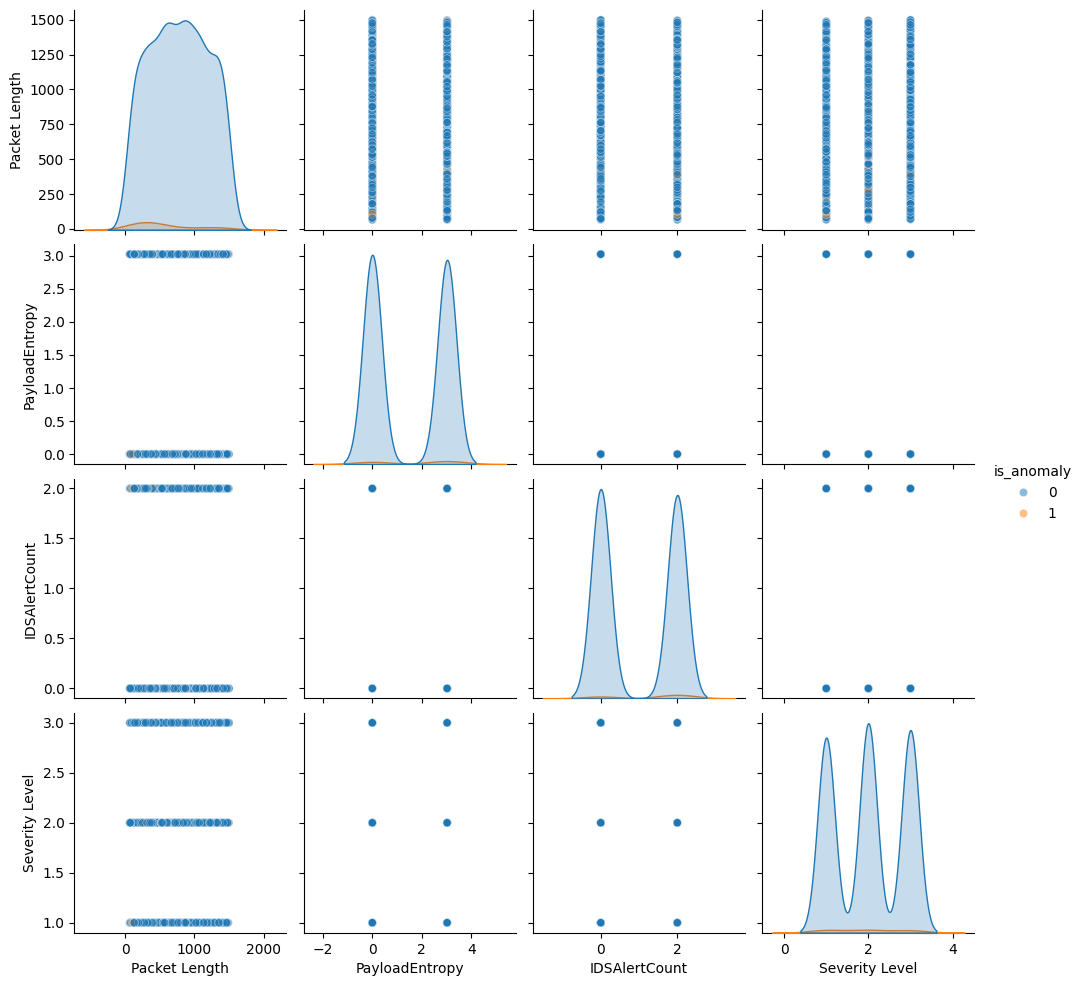

In [45]:
"""
This cell creates a pairplot to highlight interactions between columns:

Why?
    Shows how anomalies differ with varying combination of columns.

NOTE: This is a data exploration and profiling task, but needs to be in this section as we only just created the 
is_anomaly feature.
"""

sns.pairplot(
    df_clean.sample(1000),
    vars=["Packet Length", "PayloadEntropy", "IDSAlertCount", "Severity Level"],
    hue="is_anomaly",
    plot_kws={"alpha": 0.5}
)
plt.show()

In [46]:
"""
This cell shows the most suspicious events:
"""

df_clean.sort_values("anomaly_score").head(10)

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Malware Indicators,Anomaly Scores,Alerts/Warnings,Attack Type,Attack Signature,Action Taken,Severity Level,Geo-location Data,Proxy Information,SourcePortCat,DestPortCat,PayloadEntropy,FirewallLogLength,IDSAlertCount,Country,anomaly_score,is_anomaly
29174,2022-04-08 17:55:37,81.37.72.84,12.223.239.57,50945,60683,ICMP,64,Data,DNS,NaN,5.76,Alert Triggered,Malware,Known Pattern B,Blocked,3,"Dhanbad, Nagaland",NaN,dynamic,dynamic,0.000000,0,0,Nagaland,-0.023823,1
37507,2020-12-12 11:59:34,59.164.86.246,198.232.57.225,59322,59861,ICMP,224,Data,DNS,NaN,4.49,Alert Triggered,Malware,Known Pattern B,Ignored,1,"Burhanpur, Kerala",137.202.134.99,dynamic,dynamic,0.000000,8,0,Kerala,-0.023178,1
3108,2023-03-06 08:16:00,146.86.37.75,87.154.89.187,61711,64927,ICMP,210,Control,DNS,NaN,0.93,NaN,DDoS,Known Pattern A,Logged,2,"Madanapalle, Nagaland",NaN,dynamic,dynamic,0.000000,8,0,Nagaland,-0.021440,1
15590,2020-11-08 15:40:39,98.180.79.66,35.19.242.94,59532,50807,ICMP,691,Control,DNS,IoC Detected,0.03,Alert Triggered,Malware,Known Pattern B,Ignored,1,"Tinsukia, Tamil Nadu",NaN,dynamic,dynamic,3.022055,0,0,Tamil Nadu,-0.020203,1
25300,2021-06-09 15:26:21,185.44.164.66,84.111.129.81,61603,62690,TCP,1420,Data,DNS,NaN,40.29,NaN,Malware,Known Pattern A,Blocked,1,"Amaravati, Tripura",121.162.225.193,dynamic,dynamic,0.000000,0,2,Tripura,-0.019603,1
39881,2023-07-30 17:57:11,55.30.121.55,12.148.116.54,61193,63367,TCP,1450,Data,DNS,NaN,2.81,Alert Triggered,Intrusion,Known Pattern A,Blocked,3,"Guntur, Uttarakhand",NaN,dynamic,dynamic,0.000000,0,2,Uttarakhand,-0.018885,1
35724,2020-08-04 15:59:00,109.200.206.184,207.2.217.242,61602,65261,ICMP,96,Data,DNS,NaN,23.79,Alert Triggered,Malware,Known Pattern B,Logged,3,"Madhyamgram, Mizoram",NaN,dynamic,dynamic,0.000000,0,2,Mizoram,-0.018635,1
14215,2021-02-10 13:02:52,17.205.30.246,26.10.171.158,53067,53906,ICMP,207,Data,DNS,IoC Detected,14.73,Alert Triggered,Malware,Known Pattern B,Ignored,1,"Bhusawal, Rajasthan",35.8.223.96,dynamic,dynamic,3.022055,8,2,Rajasthan,-0.018269,1
10234,2023-01-15 05:17:09,112.142.188.220,183.27.62.198,59525,63434,UDP,1191,Control,DNS,IoC Detected,38.97,NaN,DDoS,Known Pattern A,Logged,3,"Anantapur, Nagaland",NaN,dynamic,dynamic,3.022055,0,2,Nagaland,-0.017860,1
15069,2020-10-28 23:42:45,162.69.198.79,56.226.108.185,54229,56944,ICMP,628,Control,DNS,NaN,1.12,Alert Triggered,Malware,Known Pattern B,Ignored,3,"Dehri, Nagaland",1.52.3.234,dynamic,dynamic,0.000000,0,0,Nagaland,-0.017632,1


In [47]:
"""
This cell shows how many anomalies were detected:

"""

df_clean["is_anomaly"].value_counts()

is_anomaly
0    39200
1      800
Name: count, dtype: int64

In [48]:
"""
Below is used to inpsect just a few anomalies:
"""

df_clean[df_clean["is_anomaly"] == 1].head(10)

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Malware Indicators,Anomaly Scores,Alerts/Warnings,Attack Type,Attack Signature,Action Taken,Severity Level,Geo-location Data,Proxy Information,SourcePortCat,DestPortCat,PayloadEntropy,FirewallLogLength,IDSAlertCount,Country,anomaly_score,is_anomaly
36805,2020-01-03 11:03:06,56.89.206.68,156.162.66.235,60890,62596,TCP,1436,Data,HTTP,NaN,9.40,NaN,Intrusion,Known Pattern B,Blocked,2,"Udaipur, Rajasthan",NaN,dynamic,dynamic,0.000000,0,2,Rajasthan,-0.012691,1
3651,2020-01-04 04:45:56,72.95.166.114,151.101.173.45,60771,59034,UDP,1124,Data,DNS,IoC Detected,57.21,Alert Triggered,DDoS,Known Pattern A,Logged,1,"Bhavnagar, Mizoram",133.20.156.192,dynamic,dynamic,3.022055,8,2,Mizoram,-0.005083,1
32622,2020-01-05 07:37:20,15.253.103.63,114.44.136.235,63368,56735,UDP,962,Data,DNS,IoC Detected,13.46,Alert Triggered,Malware,Known Pattern A,Blocked,3,"Motihari, Uttar Pradesh",NaN,dynamic,dynamic,3.022055,0,0,Uttar Pradesh,-0.000366,1
37233,2020-01-07 09:43:29,198.38.222.81,195.24.166.122,50988,60406,UDP,754,Control,DNS,NaN,13.65,NaN,Malware,Known Pattern B,Ignored,3,"Anantapur, Goa",19.202.36.28,dynamic,dynamic,0.000000,8,0,Goa,-0.006086,1
20799,2020-01-08 22:42:35,151.253.90.136,135.148.91.55,64815,57420,ICMP,1126,Data,DNS,NaN,75.07,NaN,Malware,Known Pattern B,Logged,1,"Karaikudi, Odisha",42.197.81.55,dynamic,dynamic,0.000000,0,2,Odisha,-0.003536,1
8981,2020-01-09 21:57:25,111.17.146.61,140.250.231.60,54210,61333,TCP,1165,Data,FTP,NaN,31.69,Alert Triggered,Intrusion,Known Pattern B,Blocked,3,"Ambala, Sikkim",NaN,dynamic,dynamic,0.000000,0,2,Sikkim,-0.004366,1
27330,2020-01-11 22:47:45,83.133.162.141,64.240.110.93,60247,58158,ICMP,1254,Data,HTTP,IoC Detected,0.22,Alert Triggered,Malware,Known Pattern A,Ignored,1,"Chennai, Uttarakhand",75.7.44.31,dynamic,dynamic,3.022055,8,0,Uttarakhand,-0.002477,1
16380,2020-01-13 13:18:59,80.79.97.125,177.46.170.24,60680,58189,TCP,294,Control,DNS,IoC Detected,97.80,NaN,Intrusion,Known Pattern A,Blocked,2,"Bhilai, Sikkim",110.149.100.237,dynamic,dynamic,3.022055,8,2,Sikkim,-0.007988,1
8539,2020-01-14 21:06:28,116.93.155.45,207.91.129.186,49698,58714,TCP,859,Control,DNS,NaN,59.99,NaN,Intrusion,Known Pattern A,Ignored,3,"Gopalpur, Jharkhand",NaN,dynamic,dynamic,0.000000,8,0,Jharkhand,-0.005378,1
24212,2020-01-16 09:29:54,101.92.98.237,209.171.40.50,61121,56657,UDP,776,Data,DNS,NaN,96.19,Alert Triggered,Malware,Known Pattern B,Logged,1,"Motihari, Gujarat",212.248.205.49,dynamic,dynamic,0.000000,0,2,Gujarat,-0.002825,1


In [49]:
print("anomaly_score" in df_clean.columns)

True


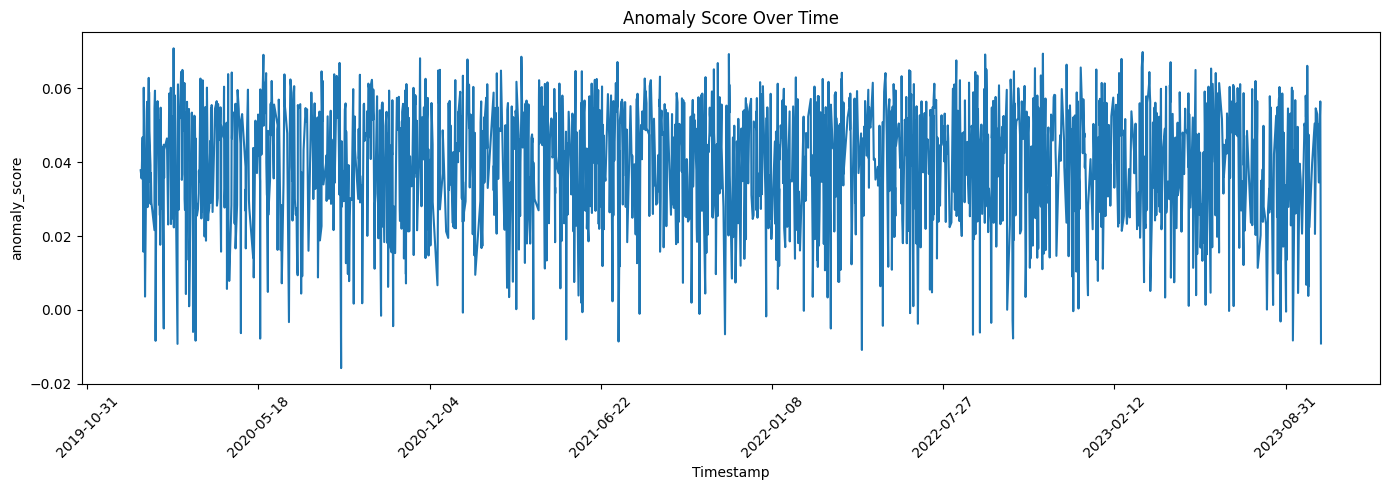

In [50]:
"""
Visualize Anamlies Over Time:

"""

# I use df_plot, which is a sample of the entire dataset, and this allows for faster plotting times.  
df_plot = df_clean.sample(2000, random_state=42)  # safe size


plt.figure(figsize=(14,5))
sns.lineplot(data=df_plot, x="Timestamp", y="anomaly_score")
plt.title("Anomaly Score Over Time")
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(10))  # reduce ticks
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [51]:
"""
Inspect Top Anomalies:



The feature 'anomaly_score' can be interpreted as follows:
    Low Scores --> Highly anomalous
    High Scores --> Normal

The output below shows data points that have a very small (all negative in fact) anomaly_scores.

But why are these data points being flagged as anomalous? There are many possible reasons:
    Packet Length: 
        Very small or large packets stand out
            Small packets can be scans or probes
            Big packets can be exfiltration or malformed payloads 

    Source/Destination Port:
        Unusual ports (High ephemeral, or unexpected well-known ports) often trigger anomalies

    Protocol:
        Rare protocols used such as ICMP, GRE, or other uncommon TCP flags.

    Traffic Type / Packet Type:
        If most traffic is HTTP/HTTPS but an anomaly is DNS or SSH, that may signal something.

    Severity Level: 
        High Severity + Low Anomaly Score == High Risk Event 

    IDSAlertCount / FirewallLogLength:
        Spikes in these fields often correlate with anomalies.

    PayloadEntropy:
        High Entropy --> Encrypted, compressed, or obfuscated payload. 
        Low Entropy --> Repetitive, or empty payload. 
        Both above can be suspicous, depending on the context.

    Country:
        If most traffic is domestic, but anomalies come from unusual countries, that's a signal.
"""

top_anomalies = df_clean.sort_values("anomaly_score").head(10)
top_anomalies

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Malware Indicators,Anomaly Scores,Alerts/Warnings,Attack Type,Attack Signature,Action Taken,Severity Level,Geo-location Data,Proxy Information,SourcePortCat,DestPortCat,PayloadEntropy,FirewallLogLength,IDSAlertCount,Country,anomaly_score,is_anomaly
29174,2022-04-08 17:55:37,81.37.72.84,12.223.239.57,50945,60683,ICMP,64,Data,DNS,NaN,5.76,Alert Triggered,Malware,Known Pattern B,Blocked,3,"Dhanbad, Nagaland",NaN,dynamic,dynamic,0.000000,0,0,Nagaland,-0.023823,1
37507,2020-12-12 11:59:34,59.164.86.246,198.232.57.225,59322,59861,ICMP,224,Data,DNS,NaN,4.49,Alert Triggered,Malware,Known Pattern B,Ignored,1,"Burhanpur, Kerala",137.202.134.99,dynamic,dynamic,0.000000,8,0,Kerala,-0.023178,1
3108,2023-03-06 08:16:00,146.86.37.75,87.154.89.187,61711,64927,ICMP,210,Control,DNS,NaN,0.93,NaN,DDoS,Known Pattern A,Logged,2,"Madanapalle, Nagaland",NaN,dynamic,dynamic,0.000000,8,0,Nagaland,-0.021440,1
15590,2020-11-08 15:40:39,98.180.79.66,35.19.242.94,59532,50807,ICMP,691,Control,DNS,IoC Detected,0.03,Alert Triggered,Malware,Known Pattern B,Ignored,1,"Tinsukia, Tamil Nadu",NaN,dynamic,dynamic,3.022055,0,0,Tamil Nadu,-0.020203,1
25300,2021-06-09 15:26:21,185.44.164.66,84.111.129.81,61603,62690,TCP,1420,Data,DNS,NaN,40.29,NaN,Malware,Known Pattern A,Blocked,1,"Amaravati, Tripura",121.162.225.193,dynamic,dynamic,0.000000,0,2,Tripura,-0.019603,1
39881,2023-07-30 17:57:11,55.30.121.55,12.148.116.54,61193,63367,TCP,1450,Data,DNS,NaN,2.81,Alert Triggered,Intrusion,Known Pattern A,Blocked,3,"Guntur, Uttarakhand",NaN,dynamic,dynamic,0.000000,0,2,Uttarakhand,-0.018885,1
35724,2020-08-04 15:59:00,109.200.206.184,207.2.217.242,61602,65261,ICMP,96,Data,DNS,NaN,23.79,Alert Triggered,Malware,Known Pattern B,Logged,3,"Madhyamgram, Mizoram",NaN,dynamic,dynamic,0.000000,0,2,Mizoram,-0.018635,1
14215,2021-02-10 13:02:52,17.205.30.246,26.10.171.158,53067,53906,ICMP,207,Data,DNS,IoC Detected,14.73,Alert Triggered,Malware,Known Pattern B,Ignored,1,"Bhusawal, Rajasthan",35.8.223.96,dynamic,dynamic,3.022055,8,2,Rajasthan,-0.018269,1
10234,2023-01-15 05:17:09,112.142.188.220,183.27.62.198,59525,63434,UDP,1191,Control,DNS,IoC Detected,38.97,NaN,DDoS,Known Pattern A,Logged,3,"Anantapur, Nagaland",NaN,dynamic,dynamic,3.022055,0,2,Nagaland,-0.017860,1
15069,2020-10-28 23:42:45,162.69.198.79,56.226.108.185,54229,56944,ICMP,628,Control,DNS,NaN,1.12,Alert Triggered,Malware,Known Pattern B,Ignored,3,"Dehri, Nagaland",1.52.3.234,dynamic,dynamic,0.000000,0,0,Nagaland,-0.017632,1


In [52]:
"""
This cell summarizes the anomalies identified above.

This gives:
    Common ports among anomalies
    Common Protocols
    Typical Packet Sizes 
    Typical Severity Levels

"""

top_anomalies.describe(include='all')

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Malware Indicators,Anomaly Scores,Alerts/Warnings,Attack Type,Attack Signature,Action Taken,Severity Level,Geo-location Data,Proxy Information,SourcePortCat,DestPortCat,PayloadEntropy,FirewallLogLength,IDSAlertCount,Country,anomaly_score,is_anomaly
count,10,10,10,10.000000,10.000000,10,10.000000,10,10,3,10.000000,7,10,10,10,10.000000,10,4,10,10,10.000000,10.000000,10.000000,10,10.000000,10.0
unique,NaN,10,10,NaN,NaN,3,NaN,2,1,1,NaN,1,3,2,3,NaN,10,4,1,1,NaN,NaN,NaN,7,NaN,NaN
top,NaN,81.37.72.84,12.223.239.57,NaN,NaN,ICMP,NaN,Data,DNS,IoC Detected,NaN,Alert Triggered,Malware,Known Pattern B,Ignored,NaN,"Dhanbad, Nagaland",137.202.134.99,dynamic,dynamic,NaN,NaN,NaN,Nagaland,NaN,NaN
freq,NaN,1,1,NaN,NaN,7,NaN,6,10,3,NaN,7,7,6,4,NaN,1,1,10,10,NaN,NaN,NaN,4,NaN,NaN
mean,2021-10-13 14:31:42.800000,NaN,NaN,58272.900000,60188.000000,NaN,618.100000,NaN,NaN,NaN,13.292000,NaN,NaN,NaN,NaN,2.100000,NaN,NaN,NaN,NaN,0.906617,2.400000,1.000000,NaN,-0.019953,1.0
min,2020-08-04 15:59:00,NaN,NaN,50945.000000,50807.000000,NaN,64.000000,NaN,NaN,NaN,0.030000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,-0.023823,1.0
25%,2020-11-17 02:45:22.750000,NaN,NaN,55502.250000,57673.250000,NaN,207.750000,NaN,NaN,NaN,1.542500,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,-0.021131,1.0
50%,2021-04-11 02:14:36.500000,NaN,NaN,59528.500000,61686.500000,NaN,426.000000,NaN,NaN,NaN,5.125000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,-0.019244,1.0
75%,2022-11-05 20:26:46,NaN,NaN,61499.750000,63417.250000,NaN,1066.000000,NaN,NaN,NaN,21.525000,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,NaN,2.266541,6.000000,2.000000,NaN,-0.018361,1.0
max,2023-07-30 17:57:11,NaN,NaN,61711.000000,65261.000000,NaN,1450.000000,NaN,NaN,NaN,40.290000,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,NaN,3.022055,8.000000,2.000000,NaN,-0.017632,1.0


In [53]:
normal = df_clean[df_clean["is_anomaly"] == 0]
anomalous = df_clean[df_clean["is_anomaly"] == 1]

normal["Packet Length"].describe(), anomalous["Packet Length"].describe()

(count    39200.000000
 mean       783.000102
 std        414.857320
 min         64.000000
 25%        424.000000
 50%        785.000000
 75%       1143.000000
 max       1500.000000
 Name: Packet Length, dtype: float64,
 count     800.000000
 mean      705.631250
 std       464.561718
 min        64.000000
 25%       269.000000
 50%       631.500000
 75%      1151.750000
 max      1497.000000
 Name: Packet Length, dtype: float64)

<Axes: xlabel='Packet Length', ylabel='anomaly_score'>

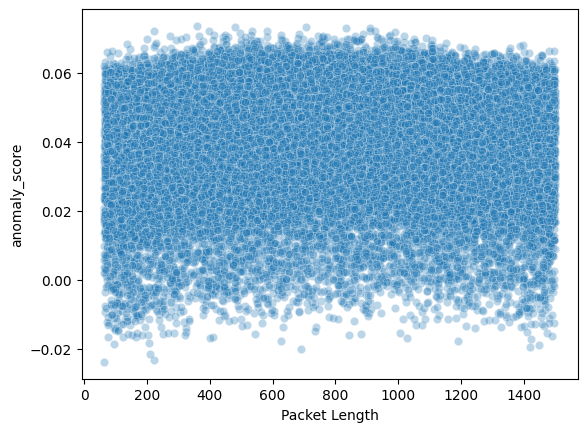

In [57]:
"""
This cell gives a scatter plot showing the packet length vs anomaly score relationship

"""

sns.scatterplot(data=df_clean, x="Packet Length", y="anomaly_score", alpha=0.3)

<Axes: xlabel='PayloadEntropy', ylabel='anomaly_score'>

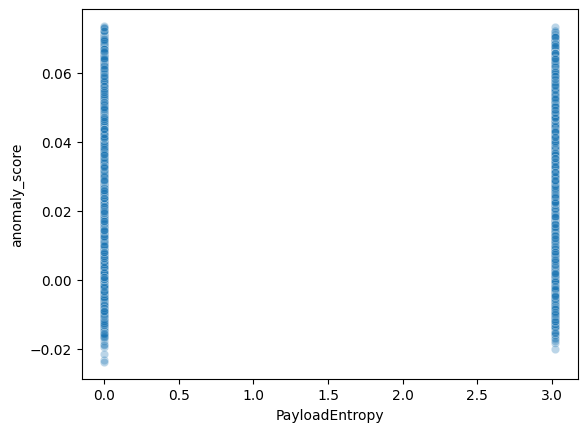

In [58]:
"""
This cell gives a scatter plot showing the entropy vs anomaly score relationship
"""
sns.scatterplot(data=df_clean, x="PayloadEntropy", y="anomaly_score", alpha=0.3)

([0, 1, 2], [Text(0, 0, 'ICMP'), Text(1, 0, 'TCP'), Text(2, 0, 'UDP')])

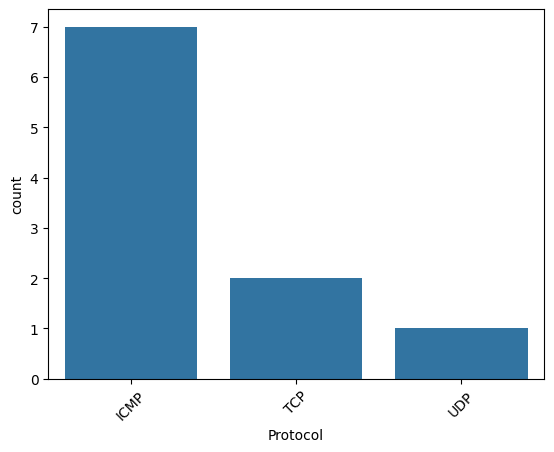

In [59]:
"""
This cell gives a bar chart showing the protocol distribution among anomalies. 
"""
sns.countplot(data=top_anomalies, x="Protocol")
plt.xticks(rotation=45)


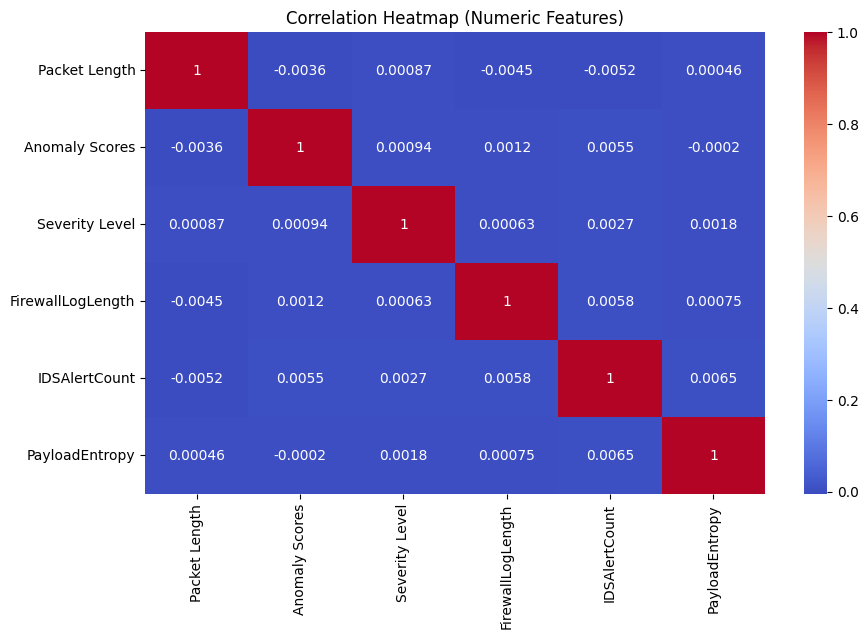

In [60]:
"""
This cell performs a correlation analysis on the cleaned dataframe.

This yields a correlation heatmap of the features that tend to move together, and those that don't.

Note: This is for numeric features only!
"""

numeric_cols = [
    "Packet Length", "Anomaly Scores", "Severity Level",
    "FirewallLogLength", "IDSAlertCount", "PayloadEntropy"
]

plt.figure(figsize=(10,6))
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()


In [ ]:
"""
The below cells engineer combined features to ID if there are any combo of features that are better 
indicative of a anomalous behavior.

These cells create 4 engineered features:
1) Entropy + Packet Length 
2) Alert Density (Number of alerts per byte of traffic)
3) Port Rarity Score (Port categories mapped to a numeric rarity value)
4) Threat Intensity (Severity + Alerts + Entropy) 

"""

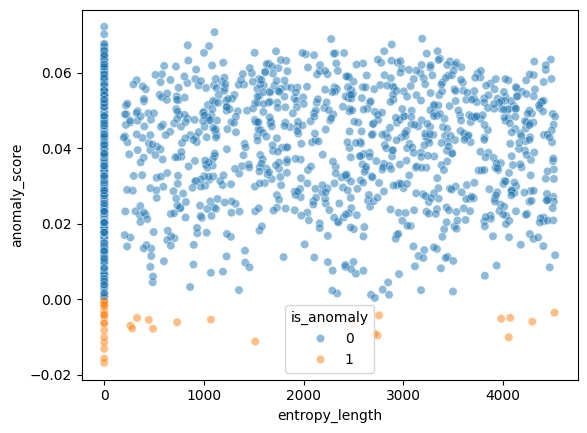

In [61]:
"""
This cell creates the first combined feature Entropy + Packet Length

Why? 
    High entropy + large packet = possible exfiltration
    Low entropy + small packet = scanning / probing
"""
df_clean["entropy_length"] = df_clean["PayloadEntropy"] * df_clean["Packet Length"]

sns.scatterplot(
    data=df_clean.sample(2000),
    x="entropy_length",
    y="anomaly_score",
    hue="is_anomaly",
    alpha=0.5
)
plt.show()


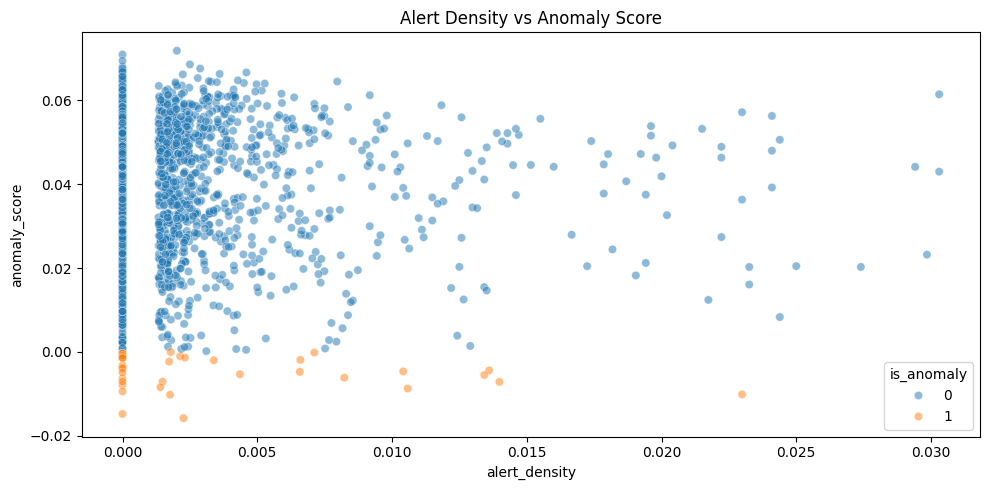

In [62]:
"""
This cell creates the second combined feature Alert Density (Number of alerts per byte of traffic)

Why? 
    This feature should spike for malicious traffic.
"""
df_clean["alert_density"] = df_clean["IDSAlertCount"] / (df_clean["Packet Length"] + 1)

plt.figure(figsize=(10,5))
sns.scatterplot(
    data=df_clean.sample(2000),
    x="alert_density",
    y="anomaly_score",
    hue="is_anomaly",
    alpha=0.5
)
plt.title("Alert Density vs Anomaly Score")
plt.tight_layout()
plt.show()


In [67]:
df_clean

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Malware Indicators,Anomaly Scores,Alerts/Warnings,Attack Type,Attack Signature,Action Taken,Severity Level,Geo-location Data,Proxy Information,SourcePortCat,DestPortCat,PayloadEntropy,FirewallLogLength,IDSAlertCount,Country,anomaly_score,is_anomaly,entropy_length,alert_density
17494,2020-01-01 00:43:27,159.63.40.232,84.35.86.112,30053,56285,UDP,1428,Data,DNS,IoC Detected,40.63,Alert Triggered,Intrusion,Known Pattern B,Blocked,3,"Baranagar, Mizoram",121.217.243.18,registered,dynamic,3.022055,8,2,Mizoram,0.010239,0,4315.494838,0.001400
33427,2020-01-01 01:14:07,203.224.244.176,12.67.144.136,9478,57024,ICMP,721,Data,DNS,IoC Detected,43.01,Alert Triggered,Malware,Known Pattern A,Blocked,1,"Bhiwandi, Bihar",101.246.69.68,registered,dynamic,3.022055,0,0,Bihar,0.031839,0,2178.901806,0.000000
26028,2020-01-01 03:02:42,152.81.184.63,81.199.149.14,37238,23561,ICMP,429,Control,DNS,NaN,41.29,Alert Triggered,Malware,Known Pattern A,Logged,3,"Thoothukudi, Uttar Pradesh",13.156.194.216,registered,registered,0.000000,0,2,Uttar Pradesh,0.047710,0,0.000000,0.004651
38419,2020-01-01 03:11:48,161.219.235.160,30.142.166.219,35780,26697,UDP,850,Data,HTTP,IoC Detected,46.70,NaN,DDoS,Known Pattern B,Ignored,3,"Patiala, Odisha",NaN,registered,registered,3.022055,8,2,Odisha,0.052597,0,2568.746928,0.002350
29339,2020-01-01 03:29:20,21.158.215.82,124.104.48.211,4056,31626,UDP,1440,Control,FTP,NaN,99.78,NaN,DDoS,Known Pattern A,Ignored,3,"Sonipat, Odisha",221.191.39.129,registered,registered,0.000000,0,0,Odisha,0.038393,0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4778,2023-10-11 12:29:23,130.231.62.201,137.34.162.176,60626,52879,UDP,392,Control,DNS,IoC Detected,30.28,Alert Triggered,Intrusion,Known Pattern A,Ignored,3,"Bellary, Gujarat",NaN,dynamic,dynamic,3.022055,8,0,Gujarat,-0.004585,1,1184.645642,0.000000
13787,2023-10-11 12:36:21,15.87.212.52,155.139.226.246,21572,24782,UDP,321,Control,DNS,NaN,2.02,Alert Triggered,Intrusion,Known Pattern B,Logged,2,"Karaikudi, Mizoram",72.98.246.186,registered,registered,0.000000,8,0,Mizoram,0.043630,0,0.000000,0.000000
29107,2023-10-11 17:44:41,19.103.201.84,153.183.223.203,18063,22086,UDP,922,Data,HTTP,IoC Detected,90.61,NaN,DDoS,Known Pattern A,Ignored,1,"Vijayanagaram, Telangana",NaN,registered,registered,3.022055,8,2,Telangana,0.049417,0,2786.334903,0.002167
27995,2023-10-11 18:50:41,173.249.245.31,17.244.142.70,15750,32560,UDP,1409,Control,FTP,NaN,63.98,Alert Triggered,Intrusion,Known Pattern B,Ignored,1,"Satara, Kerala",136.48.104.23,registered,registered,0.000000,8,0,Kerala,0.050011,0,0.000000,0.000000


In [76]:
"""
This cell creates the third combined feature Port Rarity Score (Port categories mapped to a numeric rarity value) 

Why? 
    Allows us to see when rare ports are interacted with.


TODO!!
"""



'\nThis cell creates the third combined feature Port Rarity Score (Port categories mapped to a numeric rarity value) \n\nWhy? \n    Allows us to see when rare ports are interacted with.\n\n\nTODO!!\n'

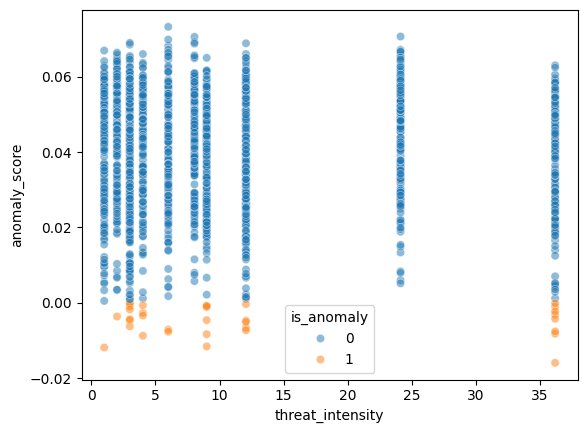

In [77]:
"""
This cell creates the fourth combined feature Threat Intensity (Severity + Alerts + Entropy).


Why? 
    Allows us to ID when a highly intense threat is present.



But why does the plot show vertical groupings?
    Severity can have values in range of 1–5,
    and IDSAlertCount can have values in range of 0–3,
    and Entropy is often in range of 0–2.

    Thus this creates clusters, and these clusters are seen in the verticle bands.

"""

df_clean["threat_intensity"] = (
    df_clean["Severity Level"] *
    (df_clean["IDSAlertCount"] + 1) *
    (df_clean["PayloadEntropy"] + 1)
)


sns.scatterplot(
    data=df_clean.sample(2000),
    x="threat_intensity",
    y="anomaly_score",
    hue="is_anomaly",
    alpha=0.5
)
plt.show()


In [78]:
"""
This cell trains a model to explain the anomalies. 

It takes the anomaly labels (is_anomaly), 
trains a simple decision tree classifier, 
and extracts feature importance.

This allows us to see which features drive anomalies.


What do the results mean?
    port_rarity          0.803117
        This is the most predictive feature of anomalous behaviour in the given dataset.
    
    Packet Length        0.163262
        Packet length is also predictive, but less so.
        
    Severity Level       0.021090
        This has a small predictive effect.        

    threat_intensity     0.012521
        This has a small predictive effect.
        
    FirewallLogLength    0.000010
        This has a very small predictive effect.
"""

from sklearn.tree import DecisionTreeClassifier

X = df_clean[[
    "Packet Length", "PayloadEntropy", "IDSAlertCount",
    "Severity Level", "FirewallLogLength", "entropy_length",
    "alert_density", "port_rarity", "threat_intensity"
]]

y = df_clean["is_anomaly"]

tree = DecisionTreeClassifier(max_depth=4)
tree.fit(X, y)

importances = pd.Series(tree.feature_importances_, index=X.columns)
importances.sort_values(ascending=False)

port_rarity          0.816611
Packet Length        0.121475
alert_density        0.029646
FirewallLogLength    0.014611
IDSAlertCount        0.008110
entropy_length       0.008079
threat_intensity     0.001469
Severity Level       0.000000
PayloadEntropy       0.000000
dtype: float64

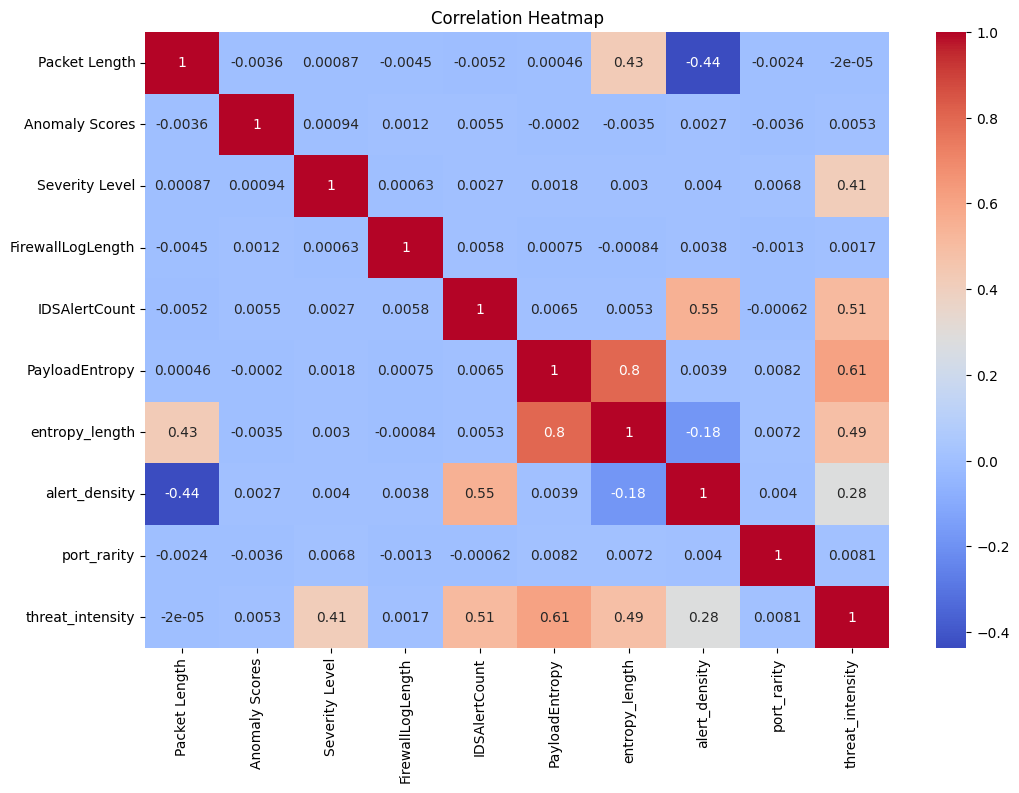

In [79]:
"""
This cell creates a feature interaction correlation heatmap.
"""

numeric_cols = [
    "Packet Length", "Anomaly Scores", "Severity Level",
    "FirewallLogLength", "IDSAlertCount", "PayloadEntropy",
    "entropy_length", "alert_density", "port_rarity", "threat_intensity"
]

plt.figure(figsize=(12,8))
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

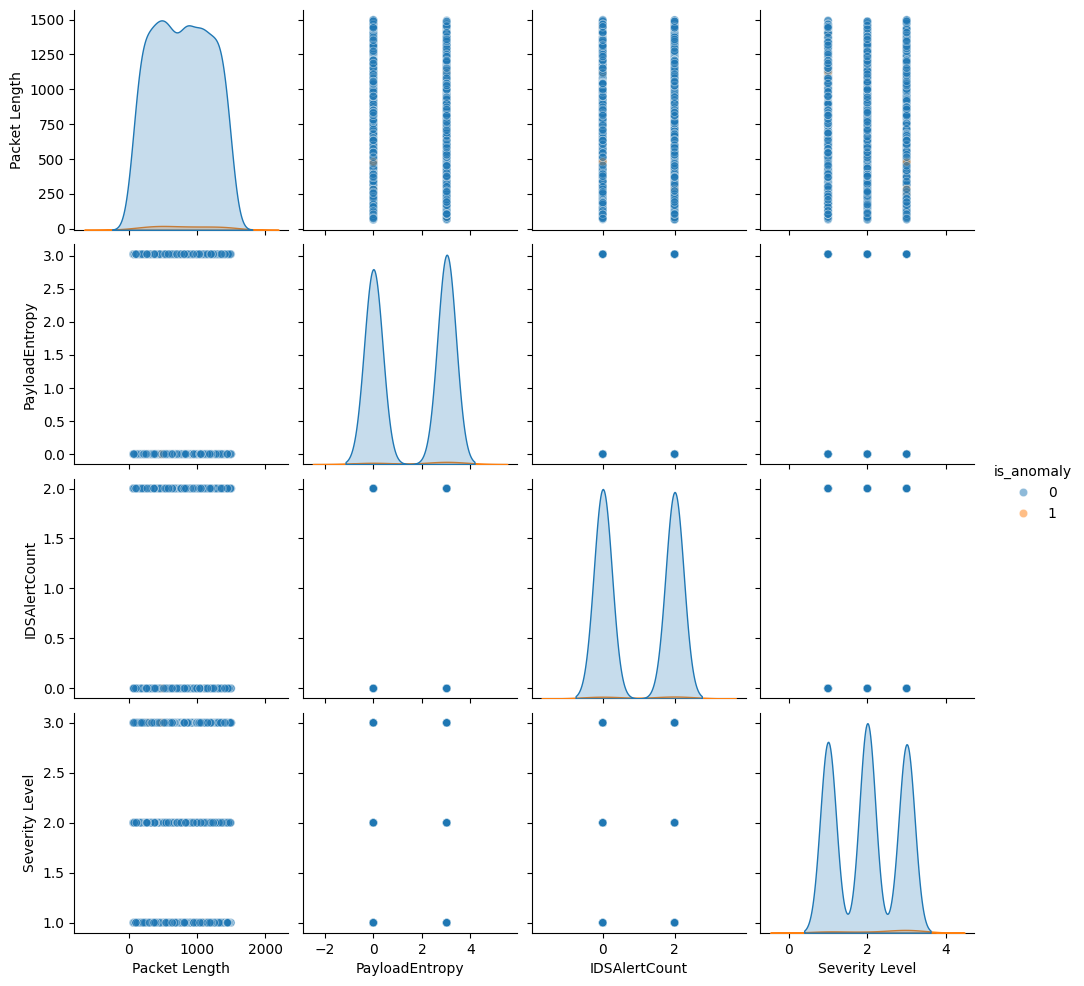

In [82]:
"""
This cell allows us to analyze for possible feature interactions, or pairwise relationships.   

It does so by creating a pairplot.

These show clusters, outliers, nonlinear relationships, combinations of features that separate anomalies.
"""

sns.pairplot(
    df_clean.sample(1000),
    vars=["Packet Length", "PayloadEntropy", "IDSAlertCount", "Severity Level"], #"port_rarity"],
    hue="is_anomaly",
    plot_kws={"alpha": 0.5}
)
plt.show()

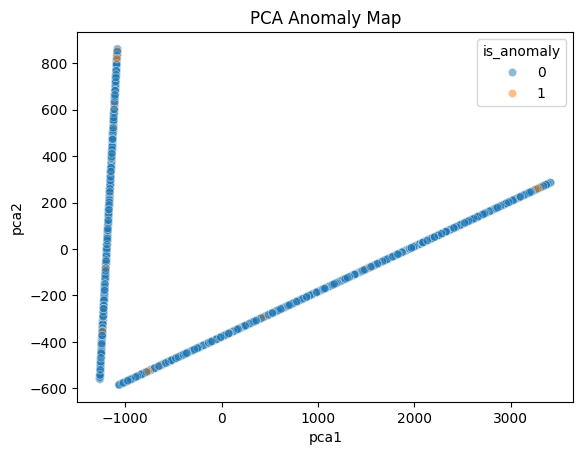

In [83]:
"""
This cell creates a 2D Anomaly Map (PCA)

This allows us to see cluster and outliers visually.

What is PCA?
    Principal Component Analysis --> A way to compress many features into 2 axes that capture the 
    most important structure in the data. (Ie IDs the combo of features that show the most variance)


How do PCA Anomaly Maps work? 
    When we plot pca1 vs pca2, 
        each point == one row/one event 
        nearby points == similar feature patterns 
        far points == very different behaviour
        coloring by is_anomalous shows where weird stuff lives 


How do we interpret the PCA anomaly map?
    Clusters --> Normal behavior 
    Isolated Points --> Anomalies
    Elongated Shapes --> Correlated features
    Multiple Islands --> Different traffic types or behaviours

In the below graph we see 2 lines extending out from the origin.
    This says that the data lies mostly along 2 dominant "directions" in feature space.
        This is the case as there are 2 dominant predictive features (port rarity and packet length)

""" 

from sklearn.decomposition import PCA

X = df_clean[numeric_cols].fillna(0)
pca = PCA(n_components=2)
coords = pca.fit_transform(X)

df_clean["pca1"] = coords[:,0]
df_clean["pca2"] = coords[:,1]

sns.scatterplot(
    data=df_clean.sample(3000),
    x="pca1",
    y="pca2",
    hue="is_anomaly",
    alpha=0.5
)
plt.title("PCA Anomaly Map")
plt.show()


In [84]:
"""
This cell creates a decision tree model that explains why a data point was flagged?

"""

from sklearn.tree import DecisionTreeClassifier

X = df_clean[numeric_cols]
y = df_clean["is_anomaly"]

tree = DecisionTreeClassifier(max_depth=4)
tree.fit(X, y)

importances = pd.Series(tree.feature_importances_, index=X.columns)
importances.sort_values(ascending=False)


port_rarity          0.783540
Packet Length        0.109812
Anomaly Scores       0.061045
alert_density        0.035054
entropy_length       0.007751
Severity Level       0.002798
PayloadEntropy       0.000000
IDSAlertCount        0.000000
FirewallLogLength    0.000000
threat_intensity     0.000000
dtype: float64

In [70]:
"""
This cell defines a small function that explains why an event looks suspicious based on key features.
"""

def explain_anomaly(row):
    reasons = []

    if row["port_rarity"] >= 3:
        reasons.append("unusual combination of source and destination ports")
    if row["Packet Length"] > df_clean["Packet Length"].quantile(0.95):
        reasons.append("unusually large packet size")
    if row["Packet Length"] < df_clean["Packet Length"].quantile(0.05):
        reasons.append("unusually small packet size")
    if row["PayloadEntropy"] > df_clean["PayloadEntropy"].quantile(0.95):
        reasons.append("high payload entropy (possible obfuscation/encryption)")
    if row["IDSAlertCount"] > 0:
        reasons.append("associated IDS alerts")
    if row["Severity Level"] >= df_clean["Severity Level"].quantile(0.9):
        reasons.append("high severity level")

    if not reasons:
        reasons.append("unusual combination of features compared to normal traffic")

    return f"Flagged due to: {', '.join(reasons)}."

# Below allows us to see the full output under the explanation column. 
pd.set_option("display.max_colwidth", None)

top_anoms = df_clean[df_clean["is_anomaly"] == 1].sort_values("anomaly_score").head(10).copy()
top_anoms["explanation"] = top_anoms.apply(explain_anomaly, axis=1)
top_anoms[[
    "Timestamp", "Source IP Address", "Destination IP Address",
    "Source Port", "Destination Port", "anomaly_score", "explanation"
]]


,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,anomaly_score,explanation
25784,2021-04-27 18:24:19,19.4.18.135,215.114.173.178,55955,63047,-0.031836,"Flagged due to: unusual combination of source and destination ports, unusually small packet size, associated IDS alerts."
29174,2022-04-08 17:55:37,81.37.72.84,12.223.239.57,50945,60683,-0.027435,"Flagged due to: unusual combination of source and destination ports, unusually small packet size, high severity level."
23083,2022-10-19 16:44:31,221.135.105.168,19.235.115.204,55026,58213,-0.025120,"Flagged due to: unusual combination of source and destination ports, unusually small packet size, associated IDS alerts, high severity level."
3108,2023-03-06 08:16:00,146.86.37.75,87.154.89.187,61711,64927,-0.023669,Flagged due to: unusual combination of source and destination ports.
15051,2023-01-10 18:20:58,196.227.73.234,37.216.169.127,55390,54186,-0.023373,"Flagged due to: unusual combination of source and destination ports, unusually small packet size."
18940,2020-03-02 13:05:02,18.164.19.95,19.38.75.135,52768,49899,-0.023208,"Flagged due to: unusual combination of source and destination ports, unusually large packet size, associated IDS alerts."
26253,2021-06-26 20:09:12,91.252.215.69,182.107.41.107,49161,51388,-0.022104,"Flagged due to: unusual combination of source and destination ports, associated IDS alerts, high severity level."
14446,2020-11-21 11:44:21,197.240.155.194,91.64.95.52,56973,61646,-0.022064,"Flagged due to: unusual combination of source and destination ports, unusually small packet size."
24161,2022-05-09 07:03:58,29.111.68.174,171.102.182.27,56441,65019,-0.021922,Flagged due to: unusual combination of source and destination ports.
37507,2020-12-12 11:59:34,59.164.86.246,198.232.57.225,59322,59861,-0.021536,Flagged due to: unusual combination of source and destination ports.


In [88]:
"""
This cell engineers new combined features based on model behavior


"""

# Ratio of firewall log length to packet length
df_clean["log_per_byte"] = df_clean["FirewallLogLength"] / (df_clean["Packet Length"] + 1)

# Severity-weighted alert density
df_clean["severity_weighted_alert_density"] = df_clean["Severity Level"] * df_clean["alert_density"]

# Binary: is dynamic port involved?
df_clean["has_dynamic_port"] = (
    (df_clean["SourcePortCat"] == "dynamic") |
    (df_clean["DestPortCat"] == "dynamic")
).astype(int)

# Length Rarity: Packet length × port rarity
#df_clean["length_rarity"] = df_clean["Packet Length"] * df_clean["port_rarity"]

# Entropy × severity
df_clean["entropy_severity"] = df_clean["PayloadEntropy"] * df_clean["Severity Level"]

# Alert density × severity
df_clean["alert_severity"] = df_clean["alert_density"] * df_clean["Severity Level"]

# Firewall log length per byte
df_clean["log_per_byte"] = df_clean["FirewallLogLength"] / (df_clean["Packet Length"] + 1)

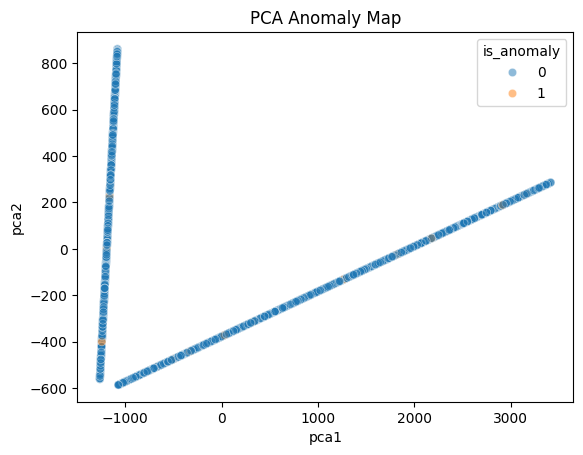

In [89]:
"""
This cell reruns the PCA map after the new features are defined.
"""

from sklearn.decomposition import PCA

X = df_clean[numeric_cols].fillna(0)
pca = PCA(n_components=2)
coords = pca.fit_transform(X)

df_clean["pca1"] = coords[:,0]
df_clean["pca2"] = coords[:,1]

sns.scatterplot(
    data=df_clean.sample(3000),
    x="pca1",
    y="pca2",
    hue="is_anomaly",
    alpha=0.5
)
plt.title("PCA Anomaly Map")
plt.show()

In [90]:
"""
This cell reruns the decision tree model after the new features are defined.

"""

from sklearn.tree import DecisionTreeClassifier

X = df_clean[numeric_cols]
y = df_clean["is_anomaly"]

tree = DecisionTreeClassifier(max_depth=4)
tree.fit(X, y)

importances = pd.Series(tree.feature_importances_, index=X.columns)
importances.sort_values(ascending=False)


port_rarity          0.783540
Packet Length        0.109812
Anomaly Scores       0.061045
alert_density        0.035054
entropy_length       0.007751
Severity Level       0.002798
PayloadEntropy       0.000000
IDSAlertCount        0.000000
FirewallLogLength    0.000000
threat_intensity     0.000000
dtype: float64

In [91]:
"""
This cell saves the df_clean dataframe to a csv file.
"""

df_clean.to_csv("df_clean.csv", index=False)